In [2]:
# General imports
from netsim.netSimPy import *
from netsim.netSimPy.common.evaluators import NetworkEvaluator
from netsim.netSimPy.common.allocators import alphaBalancing

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
traffics = [50000, 75000, 100000, 125000, 150000, 175000, 200000]
alphas = [1.0]
# alphas = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.2, 0.1, 1]

In [4]:
from typing import Any
import pandas as pd
import ast
from pathlib import Path
import glob


def read_csv(path: Path):
    # Read the CSV, skip the first comment line
    df = pd.read_csv(path.resolve(), comment="#")
    # Take the first row and convert it to a dict (columns become keys)
    row_dict = df.iloc[0].to_dict()
    # Try to parse each value that looks like a dictionary
    for key, value in row_dict.items():
        if isinstance(value, str) and value.strip().startswith(("{", "[")):
            try:
                row_dict[key] = ast.literal_eval(value)
            except Exception:
                pass  # Leave as-is if not safely parsable
    return row_dict

In [5]:
results: dict[str, list[dict[str, Any]]] = {}
loads = {}
orders = {}

for file in glob.glob("./*.csv"):
    path = Path(file)
    name = path.name
    order0, order1, alpha, load = name.split("net.evaluations")[0].split("_")

    if not alpha in results:
        results[alpha] = {}
    try:
        csv = read_csv(path)
        order = f"{order0}-{order1}"
        csv["load"] = load
        if order not in results[alpha]:
            results[alpha][order] = []
        results[alpha][order].append(csv)
    except Exception:
        pass

## Evaluation of alternative band orderings


#### Probabilidad de Bloqueo para alpha=1 y distintos ordenes de banda


CSLE-CSLE: [0.0, 0.0, 0.000388, 0.00396, 0.008375, 0.01559, 0.024425]
CSLE-ELSC: [0.0, 0.0, 0.000388, 0.00396, 0.008375, 0.01559, 0.024425]
SECL-CSEL: [0.0, 0.0, 0.0, 0.000368, 0.005997, 0.0147, 0.022488]
CLSE-CLSE: [0.0, 0.0, 0.000705, 0.005176, 0.009994, 0.016985, 0.025825]
CLSE-ESLC: [0.0, 0.0, 0.000705, 0.005176, 0.009994, 0.016985, 0.025825]
ESLC-ESLC: [0.0, 0.0, 0.0, 0.000296, 0.005028, 0.012989, 0.020609]
ESLC-CLSE: [0.0, 0.0, 0.0, 0.000296, 0.005028, 0.012989, 0.020609]
SECL-SECL: [0.0, 0.0, 0.0, 0.000368, 0.005997, 0.0147, 0.022488]
CSEL-CSEL: [0.0, 0.0, 0.0, 0.000308, 0.005538, 0.014009, 0.022543]
ELSC-CSLE: [0.0, 0.0, 0.0, 0.000292, 0.004889, 0.012669, 0.02003]
ELSC-ELSC: [0.0, 0.0, 0.0, 0.000292, 0.004889, 0.012669, 0.02003]


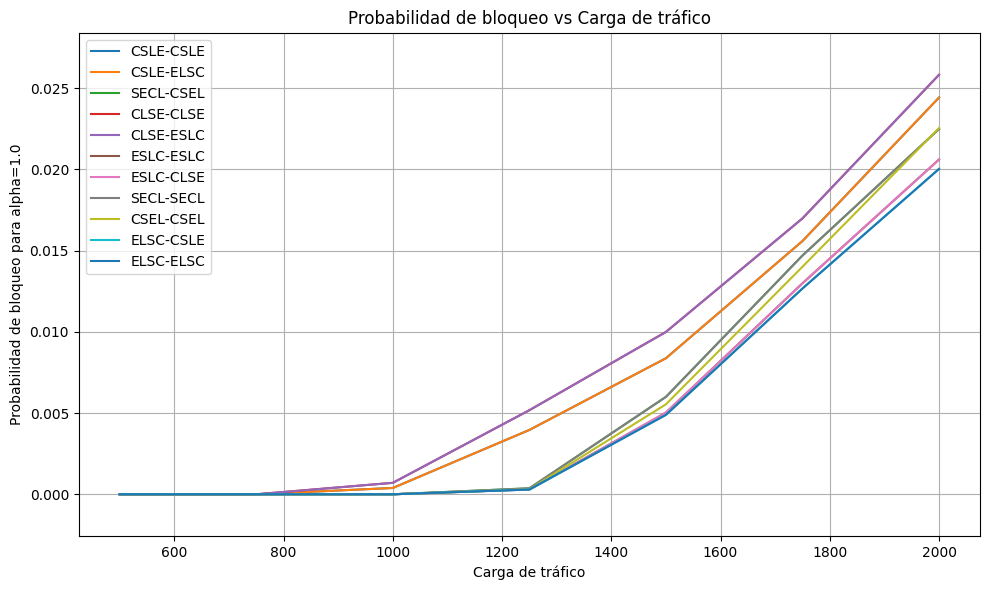

In [37]:
import matplotlib.pyplot as plt

block_prob: dict[str, list[tuple[str, float]]] = {}


for key, data in results.items():
    if key != "1.0":
        continue

    plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]
        print(f"{order_key}: {eje_y}")
        plt.plot(eje_x, eje_y, label=order_key)
        plt.legend()
    # labels = [csv["order"] for csv in data if csv[]]
    # plt.scatter(eje_x, eje_y, color="blue")
    plt.margins(y=0.1)
    # Etiquetas y título
    plt.xlabel("Carga de tráfico")
    plt.ylabel(f"Probabilidad de bloqueo para alpha={key}")
    plt.title("Probabilidad de bloqueo vs Carga de tráfico")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Porcentaje de diferencia


CSLE-CSLE: [0, 0, -44.965, -23.493, -16.2, -8.213, -5.421]
CSLE-ELSC: [0, 0, -44.965, -23.493, -16.2, -8.213, -5.421]
SECL-CSEL: [0, 0, -100.0, -92.89, -39.994, -13.453, -12.922]
CLSE-CLSE: [0, 0, 0.0, 0.0, 0.0, 0.0, 0.0]
CLSE-ESLC: [0, 0, 0.0, 0.0, 0.0, 0.0, 0.0]
ESLC-ESLC: [0, 0, -100.0, -94.281, -49.69, -23.527, -20.197]
ESLC-CLSE: [0, 0, -100.0, -94.281, -49.69, -23.527, -20.197]
SECL-SECL: [0, 0, -100.0, -92.89, -39.994, -13.453, -12.922]
CSEL-CSEL: [0, 0, -100.0, -94.049, -44.587, -17.521, -12.709]
ELSC-CSLE: [0, 0, -100.0, -94.359, -51.081, -25.411, -22.439]
ELSC-ELSC: [0, 0, -100.0, -94.359, -51.081, -25.411, -22.439]


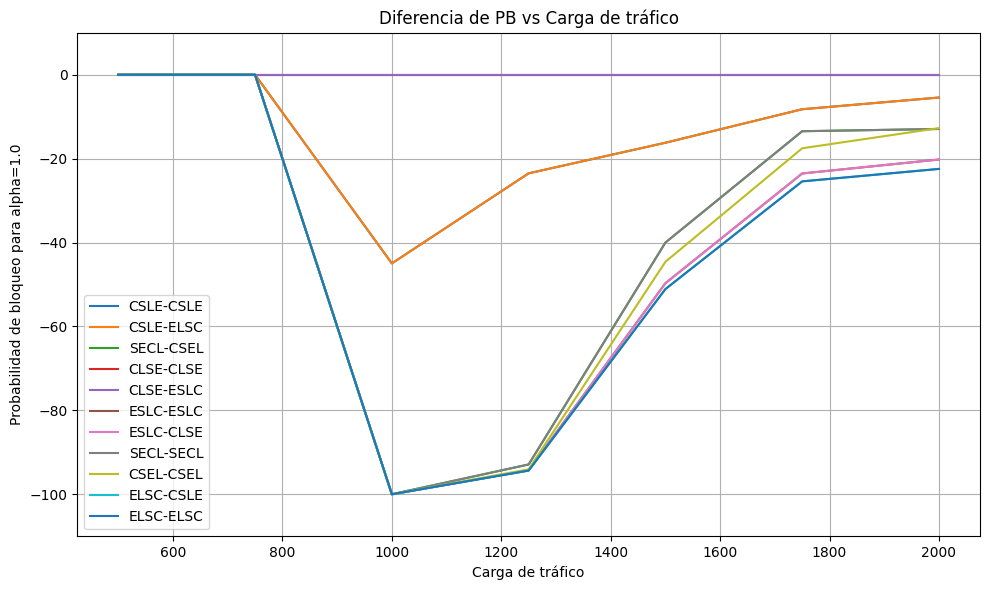

In [38]:
# Diferencia porcentual
import matplotlib.pyplot as plt

block_prob: dict[str, list[tuple[str, float]]] = {}


for key, data in results.items():
    if key != "1.0":
        continue
    plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():
        if order_key == "ELSC-SECL" or order_key == "ELSC-CSEL":
            continue
        valor_clse = results["1.0"]["CLSE-CLSE"]
        pb = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in valor_clse
        ]
        pb_ordenados = sorted(pb, key=lambda p: p[0])
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        for ind, ((pb_x, pb_y), (pa_x, pa_y)) in enumerate(
            zip(pb_ordenados, pares_ordenados)
        ):
            if pb_y == 0:
                pares_ordenados[ind] = (pa_x, 0)
            else:
                pares_ordenados[ind] = (pa_x, (pa_y - pb_y) * 100 / pb_y)
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]
        print(f"{order_key}: {list(map(lambda x: round(x, 3), eje_y))}")
        plt.plot(eje_x, eje_y, label=order_key)
        plt.legend()
    plt.margins(y=0.1)
    # Etiquetas y título
    plt.xlabel("Carga de tráfico")
    plt.ylabel(f"Probabilidad de bloqueo para alpha={key}")
    plt.title("Diferencia de PB vs Carga de tráfico")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Exploring different alpha values


#### Probabilidad de bloqueo


alpha:0.1: [0.0, 0.0, 0.000306, 0.00442, 0.009582, 0.01602, 0.024717]
alpha:0.2: [0.0, 0.0, 8.8e-05, 0.003314, 0.009146, 0.015552, 0.023906]
alpha:0.3: [0.0, 0.0, 3.4e-05, 0.002503, 0.008659, 0.015378, 0.023374]
alpha:0.4: [0.0, 0.0, 1.1e-05, 0.002046, 0.008317, 0.016217, 0.024254]
alpha:0.5: [0.0, 0.0, 6e-06, 0.001818, 0.008387, 0.016355, 0.024408]
alpha:0.6: [0.0, 0.0, 0.000299, 0.002771, 0.008738, 0.016759, 0.025115]
alpha:0.7: [0.0, 0.0, 0.000632, 0.004411, 0.009524, 0.017193, 0.026116]
alpha:0.8: [0.0, 0.0, 0.000692, 0.005184, 0.010053, 0.017217, 0.02626]
alpha:0.9: [0.0, 2e-06, 0.00071, 0.005221, 0.009923, 0.016979, 0.02597]
alpha:1.0: [0.0, 0.0, 0.000705, 0.005176, 0.009994, 0.016985, 0.025825]


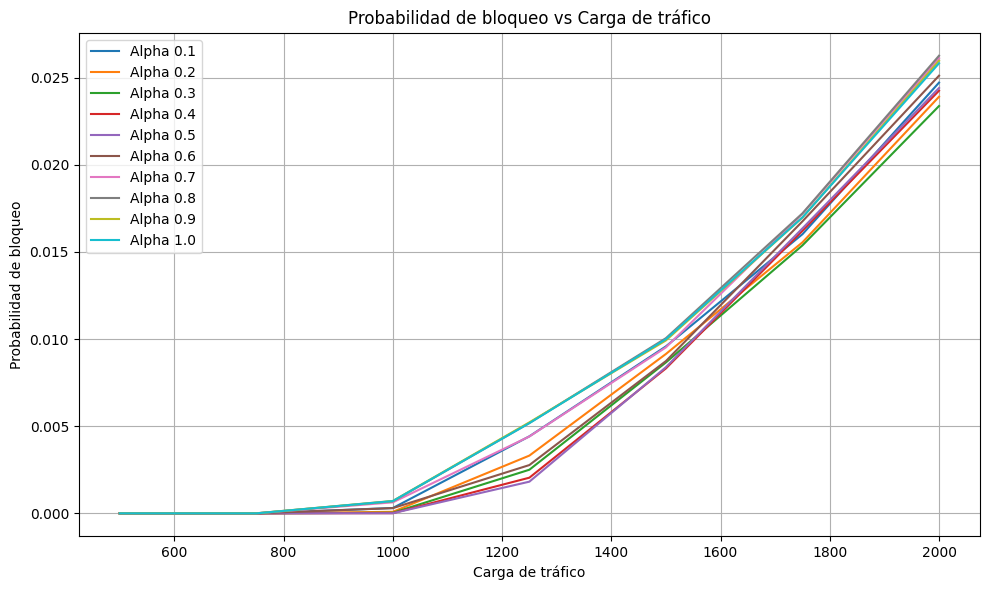

In [39]:
# Probabilidad de bloqueo
import matplotlib.pyplot as plt


alphas = ["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0"]
traffics = [500, 750, 1000, 1250, 1500, 1750, 2000]
valor_clse = results["1.0"]["CLSE-CLSE"]
eje_x = [float(load) for load in traffics]

plt.figure(figsize=(10, 6))
for a in alphas:
    data_clse = results[a]["CLSE-CLSE"]
    eje_y = []
    for load in traffics:
        for item in data_clse:
            if item["load"] == str(load):
                pb_item = item["blockedEvents"] / item["steps"]
                eje_y.append(pb_item)
    print(f"alpha:{a}: {eje_y}")
    plt.plot(eje_x, eje_y, label=f"Alpha {a}")

plt.xlabel("Carga de tráfico")
plt.ylabel("Probabilidad de bloqueo")
plt.title("Probabilidad de bloqueo vs Carga de tráfico")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Porcentaje de diferencia


alpha:0.1: [0, 0, -0.5659574468085107, -0.1460587326120556, -0.04122473484090446, -0.05681483662054758, -0.04290416263310751]
alpha:0.2: [0, 0, -0.875177304964539, -0.3597372488408037, -0.08485091054632778, -0.08436856049455403, -0.07430784123910941]
alpha:0.3: [0, 0, -0.9517730496453901, -0.5164219474497682, -0.13358014808885327, -0.0946128937297616, -0.09490803484995167]
alpha:0.4: [0, 0, -0.9843971631205674, -0.6047140649149922, -0.16780068040824492, -0.04521636738298507, -0.06083252662149078]
alpha:0.5: [0, 0, -0.9914893617021276, -0.6487635239567233, -0.16079647788673196, -0.03709155136885479, -0.05486931268151023]
alpha:0.6: [0, 0, -0.575886524822695, -0.46464451313755795, -0.1256754052431459, -0.013305858110097175, -0.02749273959341732]
alpha:0.7: [0, 0, -0.1035460992907802, -0.14779752704791346, -0.047028216930158094, 0.012246099499558426, 0.011268151016456906]
alpha:0.8: [0, 0, -0.018439716312056723, 0.0015455950540958644, 0.005903542125275168, 0.01365911098027669, 0.016844143

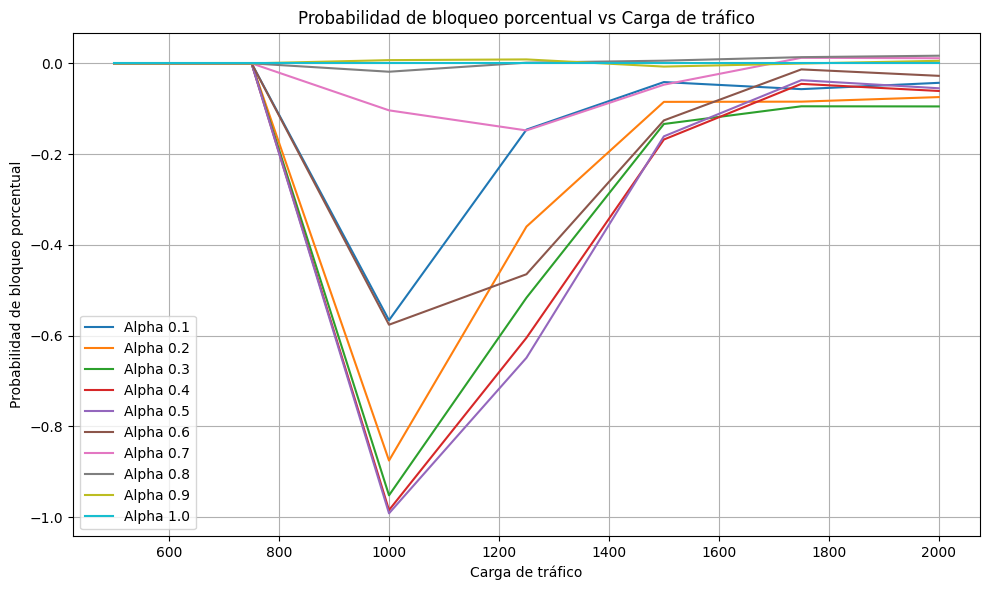

In [40]:
# Diferencia porcentual
import matplotlib.pyplot as plt


alphas = ["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0"]
traffics = [500, 750, 1000, 1250, 1500, 1750, 2000]
valor_clse = results["1.0"]["CLSE-CLSE"]
eje_x = [float(load) for load in traffics]

plt.figure(figsize=(10, 6))
for a in alphas:
    data_clse = results[a]["CLSE-CLSE"]
    eje_y = []
    for load in traffics:
        for item in data_clse:
            if item["load"] == str(load):
                pb_item = item["blockedEvents"] / item["steps"]
        for item in valor_clse:
            if item["load"] == str(load):
                pb_clse = item["blockedEvents"] / item["steps"]
        if pb_clse == 0:
            eje_y.append(0)
        else:
            eje_y.append((pb_item - pb_clse) / pb_clse)
    print(f"alpha:{a}: {eje_y}")
    plt.plot(eje_x, eje_y, label=f"Alpha {a}")

plt.xlabel("Carga de tráfico")
plt.ylabel("Probabilidad de bloqueo porcentual")
plt.title("Probabilidad de bloqueo porcentual vs Carga de tráfico")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Combined exploration of band orders and alpha values


#### Probabilidad de bloqueo -> SE DEBE HACER PARA 0.2, 0.5, 0.8


ESLC-CLSE: [0.0, 0.0, 8.9e-05, 0.00351, 0.009135, 0.015408, 0.023774]
CLSE-CLSE: [0.0, 0.0, 8.8e-05, 0.003314, 0.009146, 0.015552, 0.023906]
CLSE-ESLC: [0.0, 0.0, 0.0, 0.000333, 0.005093, 0.012968, 0.020561]
ESLC-ESLC: [0.0, 0.0, 0.0, 0.000373, 0.005143, 0.012853, 0.020644]
CSLE-CSLE: [0.0, 0.0, 5.3e-05, 0.002613, 0.007922, 0.014633, 0.022844]
SECL-CSEL: [0.0, 0.0, 0.0, 0.000327, 0.005243, 0.013435, 0.02134]
CSLE-ELSC: [0.0, 0.0, 0.0, 0.000293, 0.004768, 0.012552, 0.019925]
SECL-SECL: [0.0, 0.0, 0.0, 0.000336, 0.005537, 0.013605, 0.021199]
ELSC-CSLE: [0.0, 0.0, 4.4e-05, 0.002694, 0.007873, 0.014567, 0.022631]
ELSC-ELSC: [0.0, 0.0, 0.0, 0.00032, 0.004948, 0.012484, 0.020301]
CSEL-CSEL: [0.0, 0.0, 0.0, 0.000338, 0.005318, 0.01335, 0.021538]


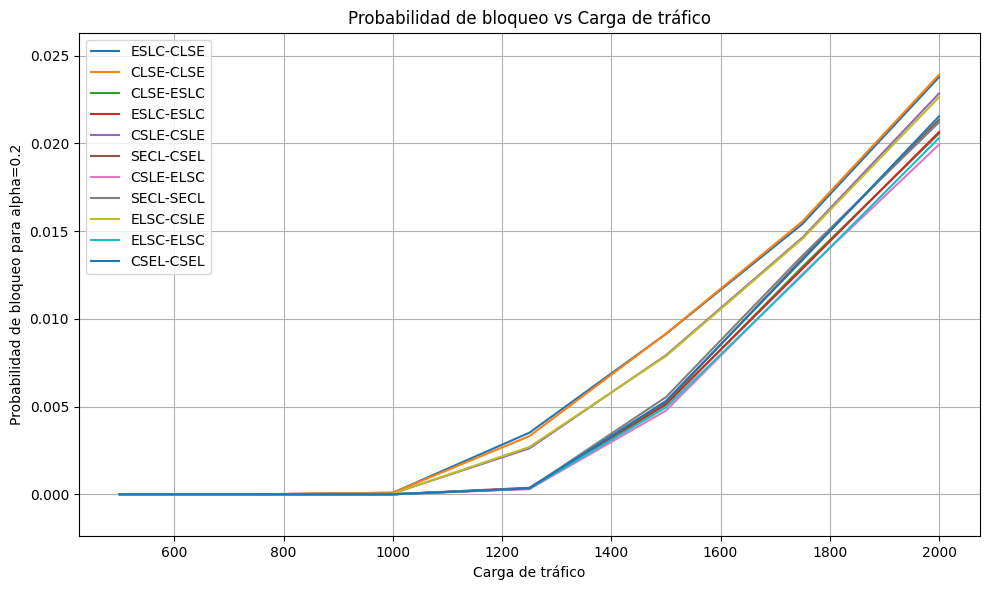

CLSE-ESLC: [0.0, 0.0, 0.000692, 0.005184, 0.010016, 0.01723, 0.026321]
SECL-CSEL: [0.0, 0.0, 0.0, 0.000495, 0.006388, 0.01475, 0.022828]
ESLC-ESLC: [0.0, 0.0, 0.0, 0.000343, 0.005223, 0.012894, 0.020601]
ESLC-CLSE: [0.0, 0.0, 0.0, 0.000344, 0.005191, 0.013033, 0.020539]
CLSE-CLSE: [0.0, 0.0, 0.000692, 0.005184, 0.010053, 0.017217, 0.02626]
CSLE-CSLE: [0.0, 0.0, 0.000415, 0.00391, 0.008523, 0.015803, 0.024653]
CSLE-ELSC: [0.0, 0.0, 0.000415, 0.00391, 0.008507, 0.015837, 0.024875]
ELSC-ELSC: [0.0, 0.0, 0.0, 0.00032, 0.004943, 0.012715, 0.020178]
ELSC-CSLE: [0.0, 0.0, 0.0, 0.000316, 0.005016, 0.012894, 0.020285]
SECL-SECL: [0.0, 0.0, 0.0, 0.00049, 0.006198, 0.014621, 0.02255]
CSEL-CSEL: [0.0, 0.0, 0.0, 0.000426, 0.005855, 0.014236, 0.02292]


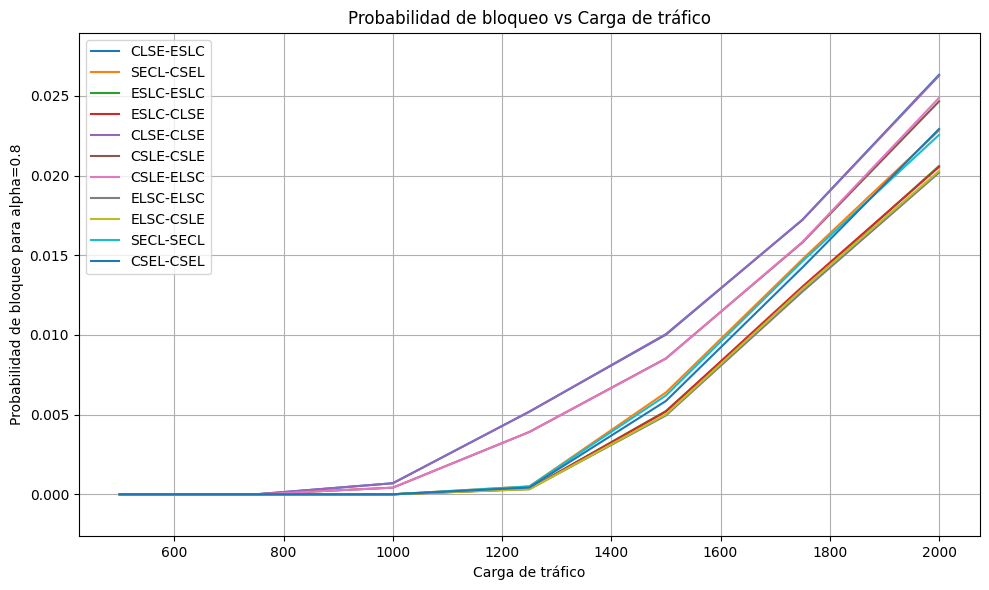

SECL-SECL: [0.0, 0.0, 2e-06, 0.000935, 0.006999, 0.015307, 0.023041]
ELSC-CSLE: [0.0, 0.0, 1e-06, 0.001823, 0.009278, 0.017428, 0.02469]
CSEL-CSEL: [0.0, 0.0, 1e-06, 0.001012, 0.007249, 0.015464, 0.023665]
CLSE-CLSE: [0.0, 0.0, 6e-06, 0.001818, 0.008387, 0.016355, 0.024408]
CSLE-CSLE: [0.0, 0.0, 1.5e-05, 0.001614, 0.008139, 0.016438, 0.024271]
CLSE-ESLC: [0.0, 0.0, 5e-06, 0.001228, 0.007606, 0.015554, 0.023428]
CSLE-ELSC: [0.0, 0.0, 8e-06, 0.001216, 0.00779, 0.015793, 0.023848]
ELSC-ELSC: [0.0, 0.0, 0.0, 0.000707, 0.005836, 0.013595, 0.021107]
ESLC-ESLC: [0.0, 0.0, 0.0, 0.000858, 0.00597, 0.013661, 0.021334]
SECL-CSEL: [0.0, 0.0, 4e-06, 0.001332, 0.007485, 0.015521, 0.023362]
ESLC-CLSE: [0.0, 0.0, 1e-05, 0.002328, 0.010024, 0.017929, 0.025061]


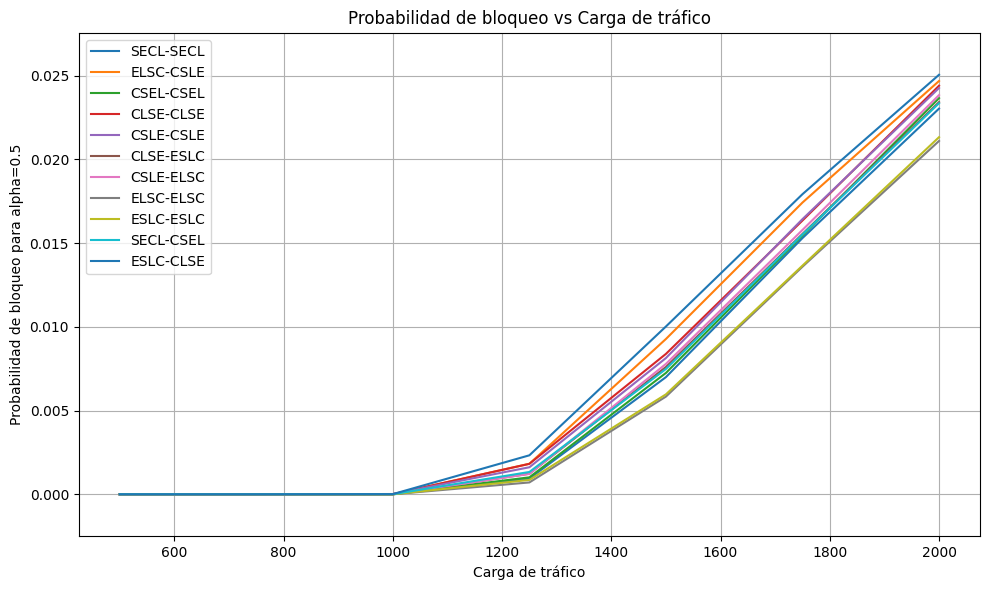

In [41]:
import matplotlib.pyplot as plt

block_prob: dict[str, list[tuple[str, float]]] = {}


for key, data in results.items():
    if key not in ["0.2", "0.5", "0.8"]:
        continue

    plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():
        if order_key == "ELSC-SECL" or order_key == "ELSC-CSEL":
            continue
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]
        print(f"{order_key}: {eje_y}")
        plt.plot(eje_x, eje_y, label=order_key)
        plt.legend()
    # labels = [csv["order"] for csv in data if csv[]]
    # plt.scatter(eje_x, eje_y, color="blue")
    plt.margins(y=0.1)
    # Etiquetas y título
    plt.xlabel("Carga de tráfico")
    plt.ylabel(f"Probabilidad de bloqueo para alpha={key}")
    plt.title("Probabilidad de bloqueo vs Carga de tráfico")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Porcentaje de diferencia -> SE DEBE HACER PARA 0.2, 0.5, 0.8


ESLC-CLSE: [0, 0, -87.376, -32.187, -8.595, -9.285, -7.942]
CLSE-CLSE: [0, 0, -87.518, -35.974, -8.485, -8.437, -7.431]
CLSE-ESLC: [0, 0, -100.0, -93.566, -49.039, -23.65, -20.383]
ESLC-ESLC: [0, 0, -100.0, -92.794, -48.539, -24.327, -20.062]
CSLE-CSLE: [0, 0, -92.482, -49.517, -20.732, -13.848, -11.543]
SECL-CSEL: [0, 0, -100.0, -93.682, -47.539, -20.901, -17.367]
CSLE-ELSC: [0, 0, -100.0, -94.339, -52.291, -26.099, -22.846]
SECL-SECL: [0, 0, -100.0, -93.509, -44.597, -19.9, -17.913]
ELSC-CSLE: [0, 0, -93.759, -47.952, -21.223, -14.236, -12.368]
ELSC-ELSC: [0, 0, -100.0, -93.818, -50.49, -26.5, -21.39]
CSEL-CSEL: [0, 0, -100.0, -93.47, -46.788, -21.401, -16.6]


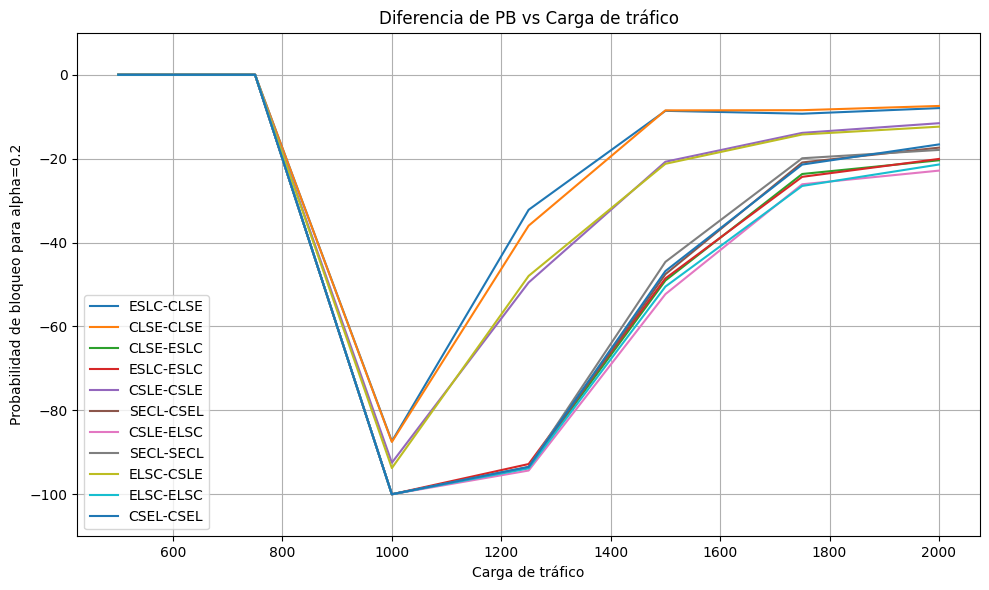

CLSE-ESLC: [0, 0, -1.844, 0.155, 0.22, 1.442, 1.921]
SECL-CSEL: [0, 0, -100.0, -90.437, -36.082, -13.159, -11.605]
ESLC-ESLC: [0, 0, -100.0, -93.373, -47.739, -24.086, -20.228]
ESLC-CLSE: [0, 0, -100.0, -93.354, -48.059, -23.268, -20.469]
CLSE-CLSE: [0, 0, -1.844, 0.155, 0.59, 1.366, 1.684]
CSLE-CSLE: [0, 0, -41.135, -24.459, -14.719, -6.959, -4.538]
CSLE-ELSC: [0, 0, -41.135, -24.459, -14.879, -6.759, -3.679]
ELSC-ELSC: [0, 0, -100.0, -93.818, -50.54, -25.14, -21.866]
ELSC-CSLE: [0, 0, -100.0, -93.895, -49.81, -24.086, -21.452]
SECL-SECL: [0, 0, -100.0, -90.533, -37.983, -13.918, -12.682]
CSEL-CSEL: [0, 0, -100.0, -91.77, -41.415, -16.185, -11.249]


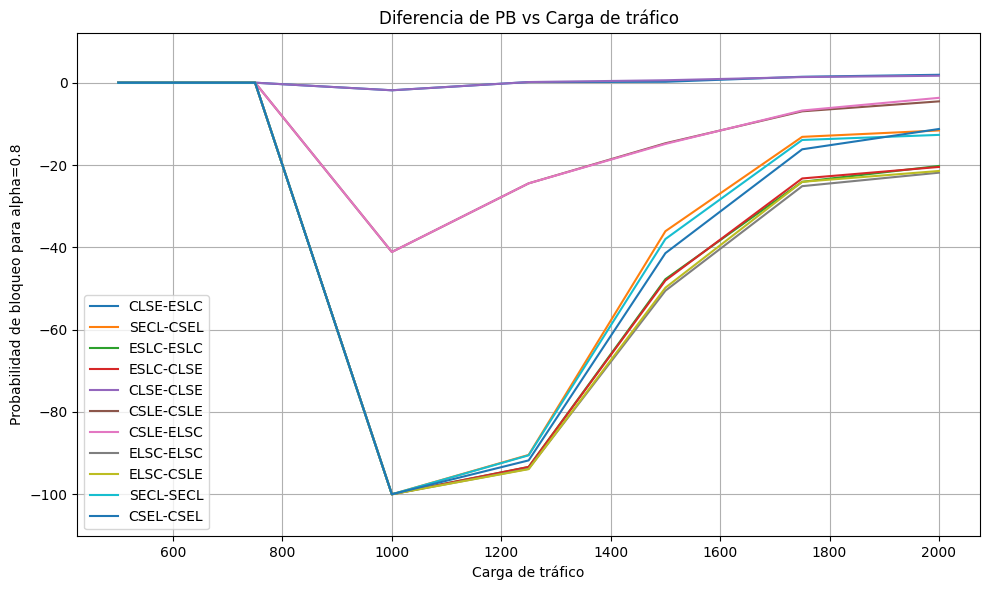

SECL-SECL: [0, 0, -99.716, -81.936, -29.968, -9.879, -10.78]
ELSC-CSLE: [0, 0, -99.858, -64.78, -7.164, 2.608, -4.395]
CSEL-CSEL: [0, 0, -99.858, -80.448, -27.466, -8.955, -8.364]
CLSE-CLSE: [0, 0, -99.149, -64.876, -16.08, -3.709, -5.487]
CSLE-CSLE: [0, 0, -97.872, -68.818, -18.561, -3.22, -6.017]
CLSE-ESLC: [0, 0, -99.291, -76.275, -23.894, -8.425, -9.282]
CSLE-ELSC: [0, 0, -98.865, -76.507, -22.053, -7.018, -7.655]
ELSC-ELSC: [0, 0, -100.0, -86.341, -41.605, -19.959, -18.269]
ESLC-ESLC: [0, 0, -100.0, -83.423, -40.264, -19.57, -17.39]
SECL-CSEL: [0, 0, -99.433, -74.266, -25.105, -8.619, -9.537]
ESLC-CLSE: [0, 0, -98.582, -55.023, 0.3, 5.558, -2.958]


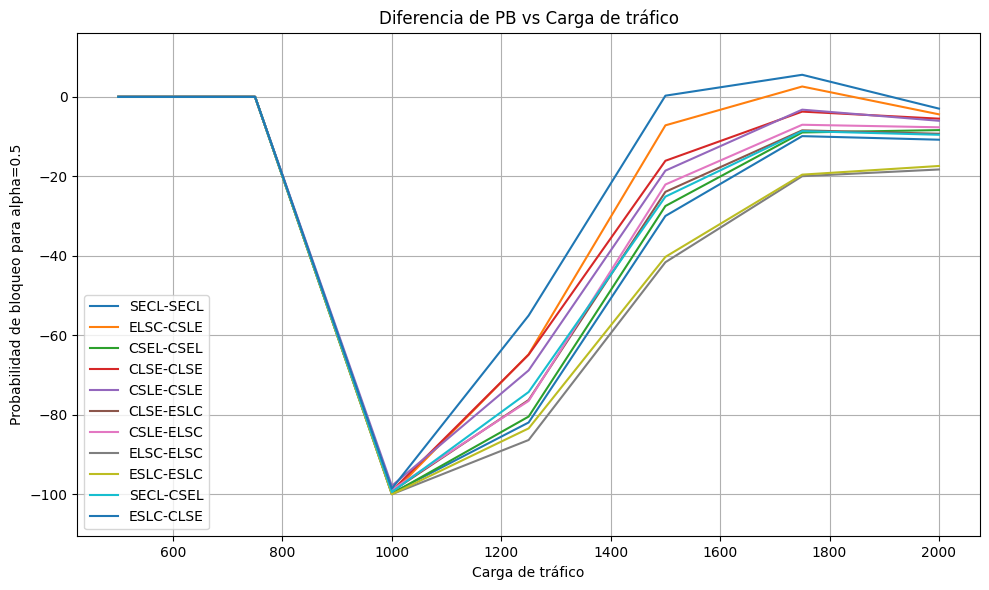

In [42]:
# Diferencia porcentual
import matplotlib.pyplot as plt

block_prob: dict[str, list[tuple[str, float]]] = {}


for key, data in results.items():
    if key not in ["0.2", "0.5", "0.8"]:
        continue
    plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():
        if order_key == "ELSC-SECL" or order_key == "ELSC-CSEL":
            continue
        valor_clse = results["1.0"]["CLSE-CLSE"]
        pb = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in valor_clse
        ]
        pb_ordenados = sorted(pb, key=lambda p: p[0])
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        for ind, ((pb_x, pb_y), (pa_x, pa_y)) in enumerate(
            zip(pb_ordenados, pares_ordenados)
        ):
            if pb_y == 0:
                pares_ordenados[ind] = (pa_x, 0)
            else:
                pares_ordenados[ind] = (pa_x, (pa_y - pb_y) * 100 / pb_y)
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]
        print(f"{order_key}: {list(map(lambda x: round(x, 3), eje_y))}")
        plt.plot(eje_x, eje_y, label=order_key)
        plt.legend()
    plt.margins(y=0.1)
    # Etiquetas y título
    plt.xlabel("Carga de tráfico")
    plt.ylabel(f"Probabilidad de bloqueo para alpha={key}")
    plt.title("Diferencia de PB vs Carga de tráfico")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Revisión de balanceo de bandas -> REVISAR


In [43]:
load = "1000"
bands_capacity = {"C": 344, "L": 480, "S": 760, "E": 1136}
idata = {}

for key, data in results.items():
    idata[key] = {}
    # key = "0.3"
    # data = results["0.3"]
    for order_key, order_data in data.items():
        # if key != "0.3":
        #     continue
        for val in order_data:
            if load == val["load"]:
                # val["totalAttendedByBand"] = {'C': 32757, 'S': 922599, 'L': 16531, 'E': 27735}
                idata[key][order_key] = val["totalAttendedByBand"]
                # print(idata)
                for key_value, value in val["totalAttendedByBand"].items():
                    idata[key][order_key][key_value] = value / bands_capacity[key_value]
        # print(f"Resultados para order_key={order_key} y order_data={order_data}:")
print(idata)

{'0.9': {'SECL-CSEL': {'C': 79.21220930232558, 'S': 1239.4842105263158, 'L': 10.245833333333334, 'E': 22.733274647887324}, 'CSEL-CSEL': {'C': 2522.9447674418607, 'S': 143.70394736842104, 'L': 23.3, 'E': 10.306338028169014}, 'ELSC-CSEL': {'C': 0.9273255813953488, 'S': 37.7, 'L': 437.25, 'E': 670.0255281690141}, 'ELSC-SECL': {'C': 0.9273255813953488, 'S': 37.7, 'L': 437.25, 'E': 670.0255281690141}, 'CLSE-CLSE': {'C': 2522.9447674418607, 'S': 45.7828947368421, 'L': 200.16875, 'E': 0.4586267605633803}, 'ESLC-CLSE': {'C': 0.8197674418604651, 'S': 288.6197368421053, 'L': 40.0375, 'E': 670.0255281690141}, 'ELSC-ELSC': {'C': 0.9273255813953488, 'S': 37.7, 'L': 437.25, 'E': 670.0255281690141}, 'ELSC-CSLE': {'C': 0.9273255813953488, 'S': 37.7, 'L': 437.25, 'E': 670.0255281690141}, 'SECL-SECL': {'C': 79.21220930232558, 'S': 1239.4842105263158, 'L': 10.245833333333334, 'E': 22.733274647887324}, 'ESLC-ESLC': {'C': 0.8197674418604651, 'S': 288.6197368421053, 'L': 40.0375, 'E': 670.0255281690141}, 'C

0.2 - ESLC-CLSE: {'C': 320.375, 'S': 321.91315789473686, 'L': 132.88333333333333, 'E': 511.67605633802816}
0.2 - CLSE-CLSE: {'C': 1442.3517441860465, 'S': 199.4092105263158, 'L': 545.4270833333334, 'E': 79.56602112676056}
0.2 - CLSE-ESLC: {'C': 1533.125, 'S': 137.6328947368421, 'L': 495.87291666666664, 'E': 114.42341549295774}
0.2 - ESLC-ESLC: {'C': 168.0, 'S': 331.59736842105264, 'L': 233.92291666666668, 'E': 508.7244718309859}
0.2 - CSLE-CSLE: {'C': 1444.3546511627908, 'S': 393.7078947368421, 'L': 249.975, 'E': 73.84066901408451}
0.2 - SECL-CSEL: {'C': 311.2151162790698, 'S': 877.2263157894737, 'L': 170.05208333333334, 'E': 127.31073943661971}
0.2 - ELSC-CSEL: {'C': 335.0348837209302, 'S': 110.33421052631579, 'L': 508.6645833333333, 'E': 490.0836267605634}
0.2 - CSLE-ELSC: {'C': 1534.6046511627908, 'S': 354.4947368421053, 'L': 160.4, 'E': 110.64084507042253}
0.2 - ELSC-SECL: {'C': 135.92151162790697, 'S': 203.4907894736842, 'L': 536.6333333333333, 'E': 476.23767605633805}
0.2 - SECL-

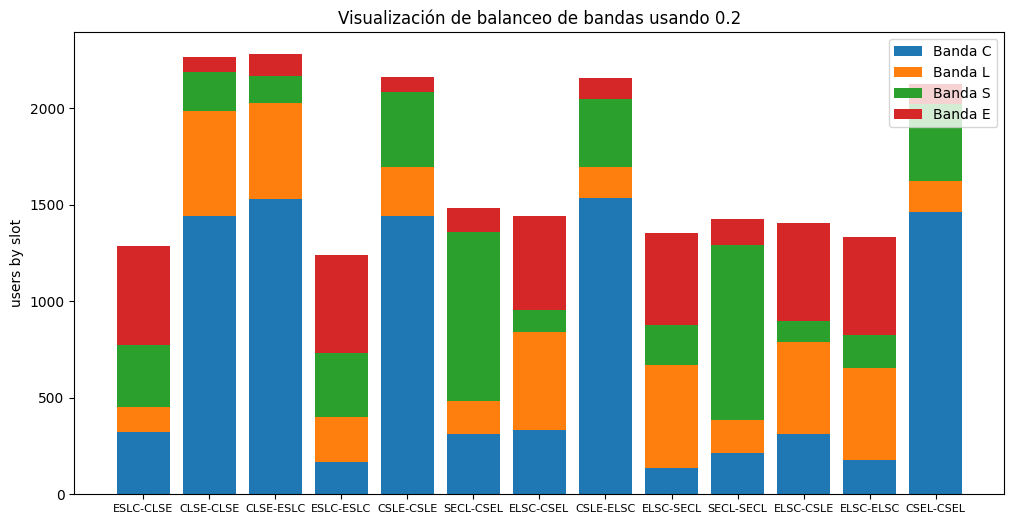

0.8 - CLSE-ESLC: {'C': 2513.2441860465115, 'S': 47.5328947368421, 'L': 203.66875, 'E': 0.7623239436619719}
0.8 - SECL-CSEL: {'C': 79.86046511627907, 'S': 1234.292105263158, 'L': 12.316666666666666, 'E': 25.135563380281692}
0.8 - ESLC-ESLC: {'C': 1.2122093023255813, 'S': 289.9815789473684, 'L': 41.84166666666667, 'E': 668.2332746478874}
0.8 - ELSC-CSEL: {'C': 1.247093023255814, 'S': 39.33289473684211, 'L': 438.6770833333333, 'E': 668.2332746478874}
0.8 - ESLC-CLSE: {'C': 1.2122093023255813, 'S': 289.9815789473684, 'L': 41.84166666666667, 'E': 668.2332746478874}
0.8 - CLSE-CLSE: {'C': 2513.2441860465115, 'S': 47.5328947368421, 'L': 203.66875, 'E': 0.7623239436619719}
0.8 - CSLE-CSLE: {'C': 2513.2441860465115, 'S': 146.84473684210528, 'L': 47.23125, 'E': 0.6654929577464789}
0.8 - CSLE-ELSC: {'C': 2513.2441860465115, 'S': 146.84473684210528, 'L': 47.23125, 'E': 0.6654929577464789}
0.8 - ELSC-ELSC: {'C': 1.247093023255814, 'S': 39.33289473684211, 'L': 438.6770833333333, 'E': 668.23327464788

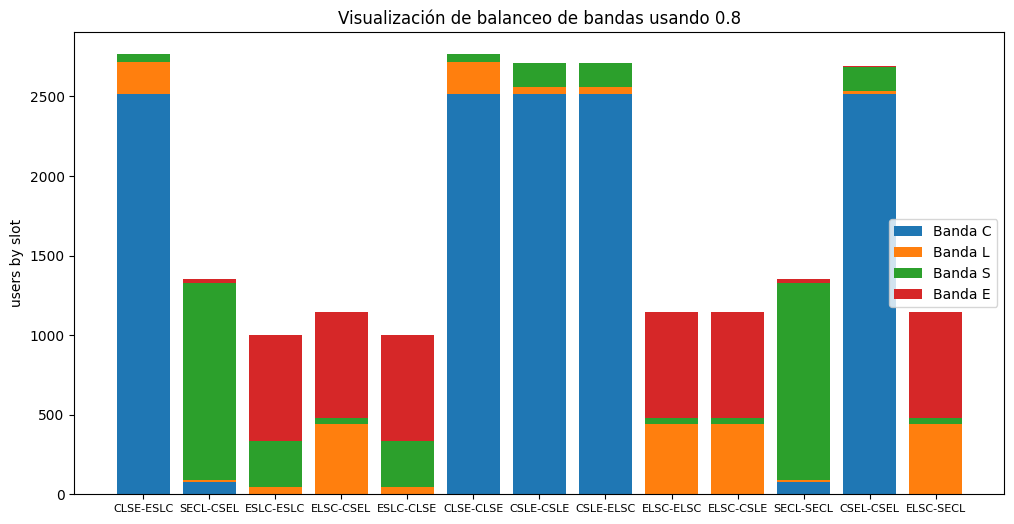

0.5 - SECL-SECL: {'C': 96.07848837209302, 'S': 1159.5013157894737, 'L': 52.43125, 'E': 53.30897887323944}
0.5 - ELSC-CSLE: {'C': 45.395348837209305, 'S': 72.48552631578947, 'L': 448.8625, 'E': 628.3802816901408}
0.5 - CSEL-CSEL: {'C': 2222.985465116279, 'S': 225.86184210526315, 'L': 52.5875, 'E': 33.798415492957744}
0.5 - CLSE-CLSE: {'C': 2218.2267441860463, 'S': 85.62631578947368, 'L': 320.1625, 'E': 15.994718309859154}
0.5 - CSLE-CSLE: {'C': 2218.8401162790697, 'S': 226.5842105263158, 'L': 97.01041666666667, 'E': 15.787852112676056}
0.5 - CLSE-ESLC: {'C': 2216.8808139534885, 'S': 84.06184210526315, 'L': 320.6354166666667, 'E': 17.25}
0.5 - CSLE-ELSC: {'C': 2216.328488372093, 'S': 226.03684210526316, 'L': 96.52291666666666, 'E': 17.12676056338028}
0.5 - ELSC-ELSC: {'C': 39.55523255813954, 'S': 73.2, 'L': 449.01666666666665, 'E': 629.606514084507}
0.5 - ESLC-ESLC: {'C': 38.98837209302326, 'S': 300.1736842105263, 'L': 90.18541666666667, 'E': 629.5484154929577}
0.5 - SECL-CSEL: {'C': 104

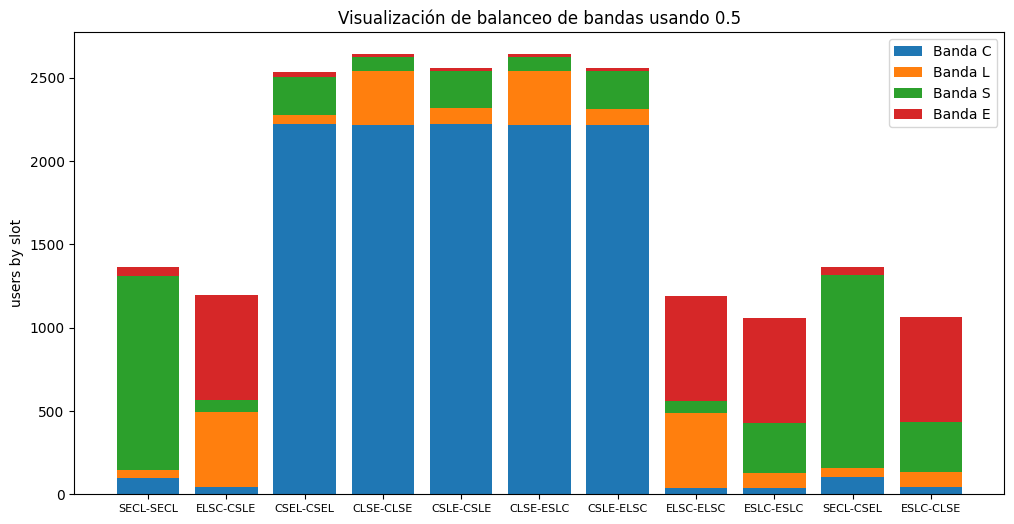

In [44]:
import matplotlib.pyplot as plt
import numpy as np

for key, data in idata.items():
    if key not in ["0.2", "0.5", "0.8"]:
        continue
    categorias = []
    # Datos: cada lista representa un tipo de mesa por categoría
    C = []
    S = []
    L = []
    E = []
    for order_key, order_data in data.items():
        categorias.append(order_key)
        for band, bandData in order_data.items():
            if band == "C":
                C.append(bandData)
            elif band == "S":
                S.append(bandData)
            elif band == "L":
                L.append(bandData)
            elif band == "E":
                E.append(bandData)

    # Posiciones en el eje X
    x = np.arange(len(categorias))
    plt.figure(figsize=(12, 6))
    # Crear barras apiladas
    plt.bar(x, C, label="Banda C")
    plt.bar(x, L, bottom=C, label="Banda L")
    plt.bar(x, S, bottom=np.array(C) + np.array(L), label="Banda S")
    plt.bar(x, E, bottom=np.array(C) + np.array(L) + np.array(S), label="Banda E")

    # Etiquetas y formato
    plt.xticks(x, categorias, fontsize=8)
    plt.ylabel("users by slot")
    plt.title(f"Visualización de balanceo de bandas usando {key}")
    plt.legend()

    # for key in idata:
    # if key not in ["0.2", "0.5", "0.8"]:
    #     continue
    for order_key, order_data in data.items():
        # if order_key == "ELSC-SECL" or order_key == "ELSC-CSEL":
        #     continue
        print(f"{key} - {order_key}: {order_data}")

    # Mostrar gráfico
    plt.show()

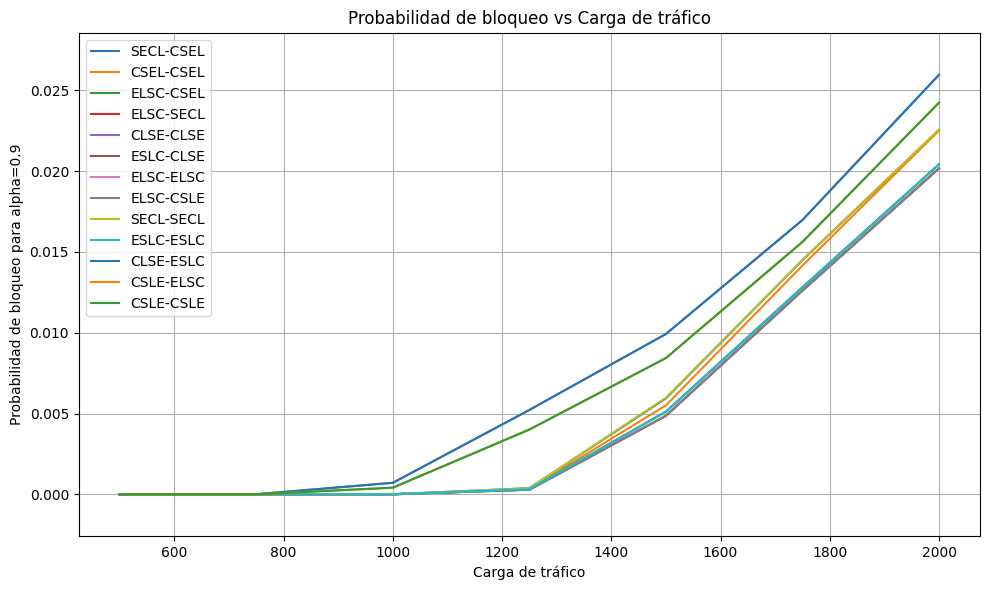

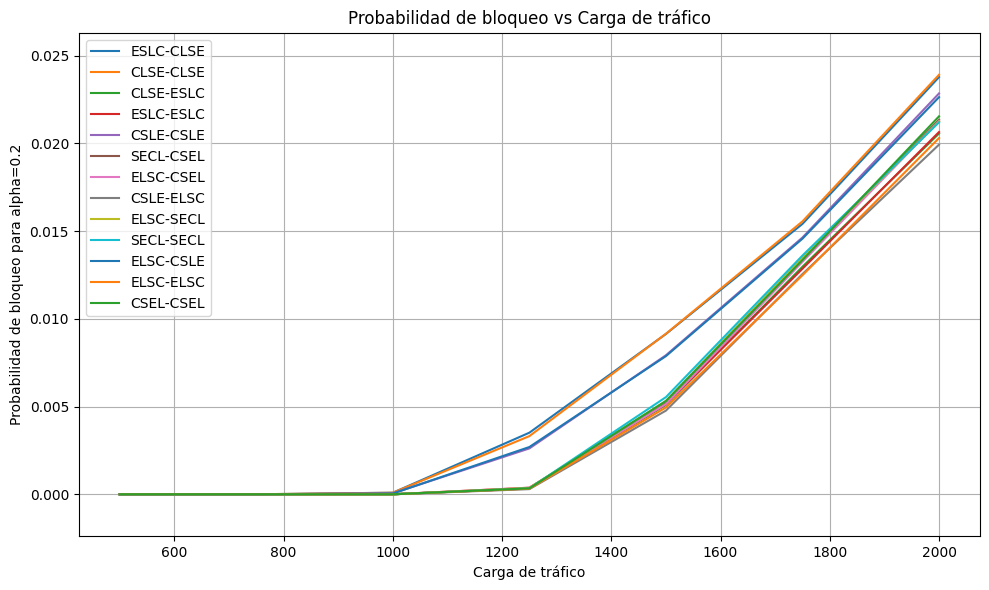

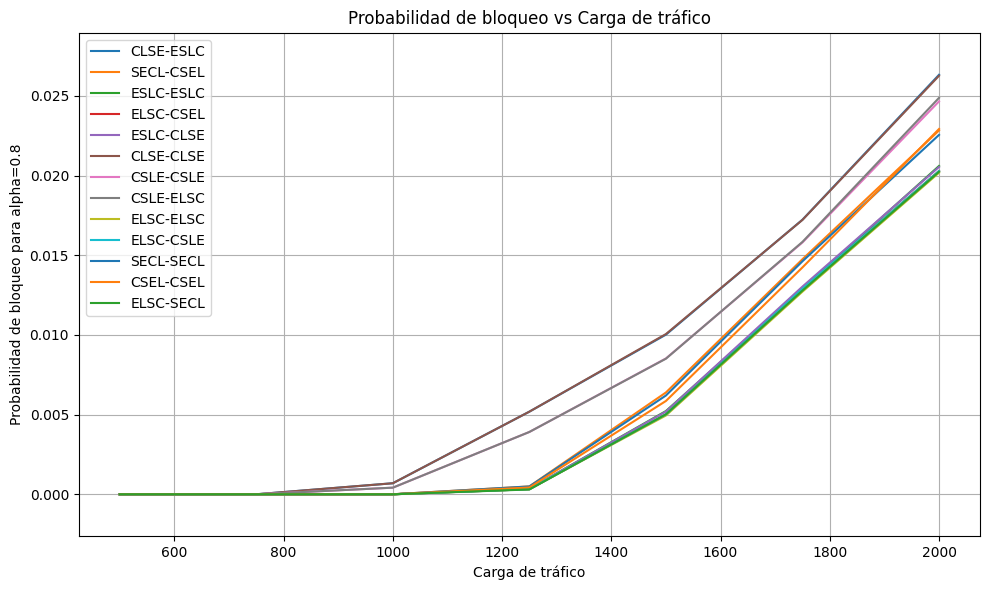

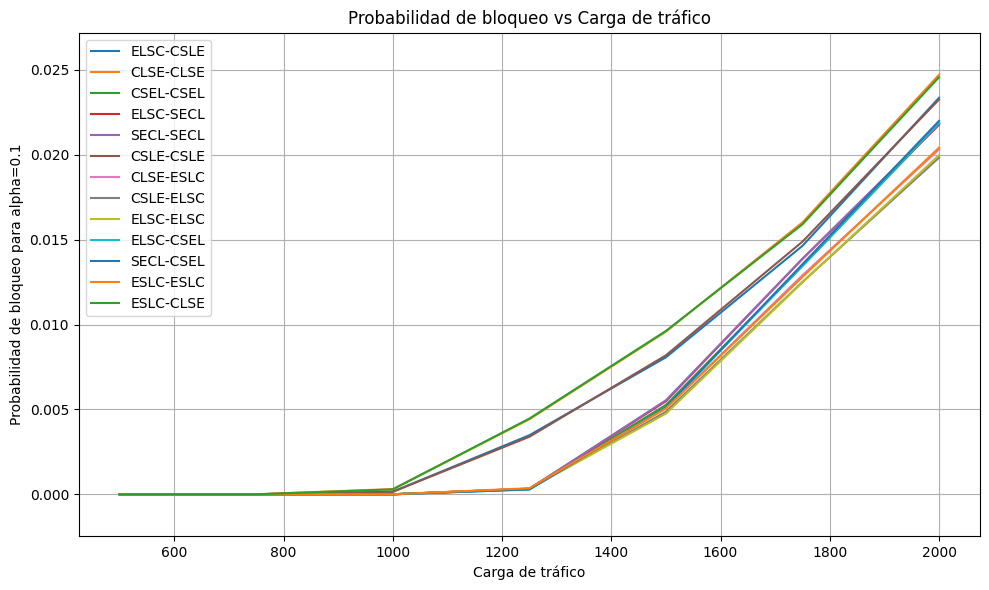

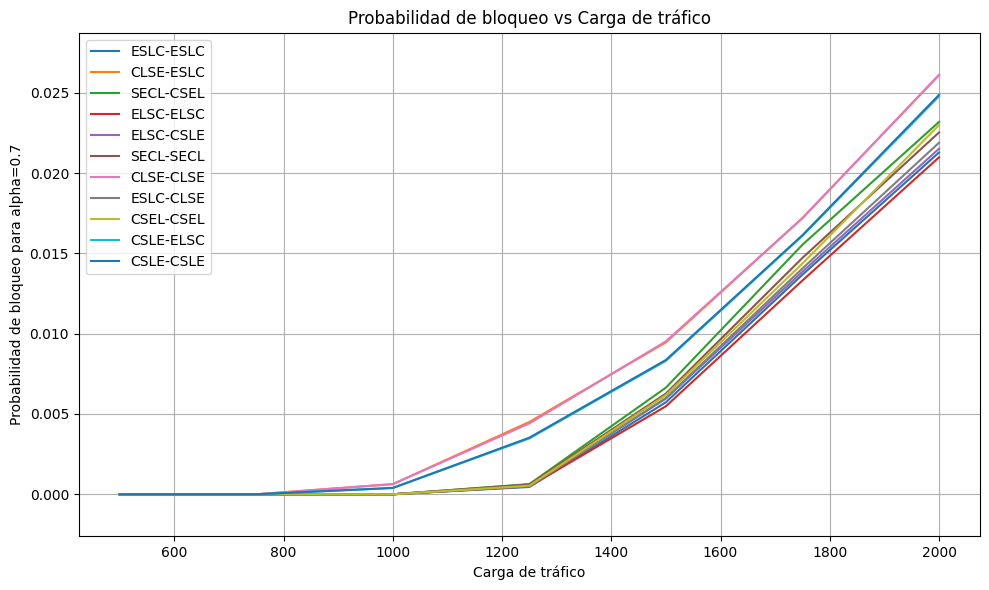

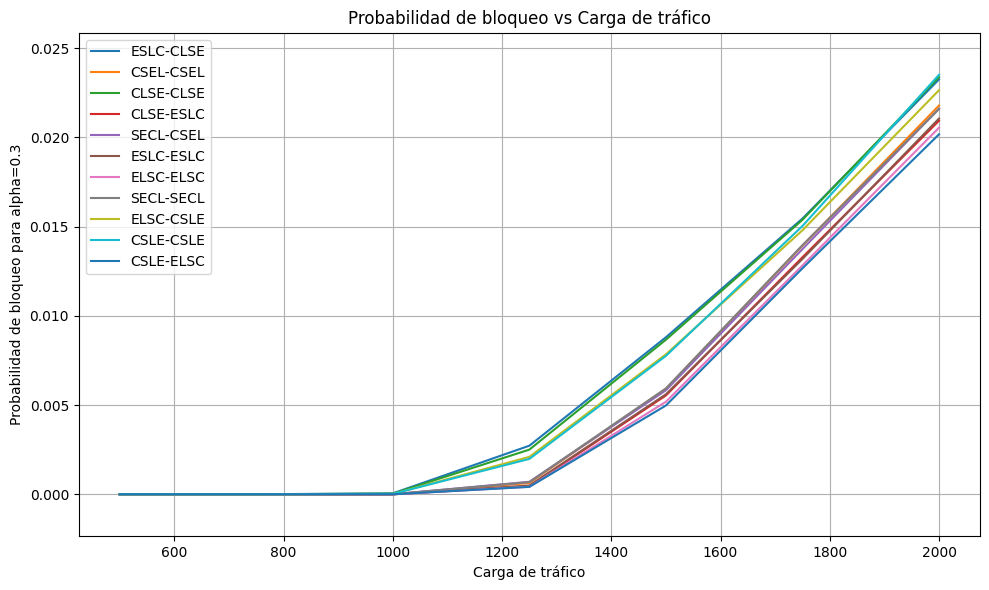

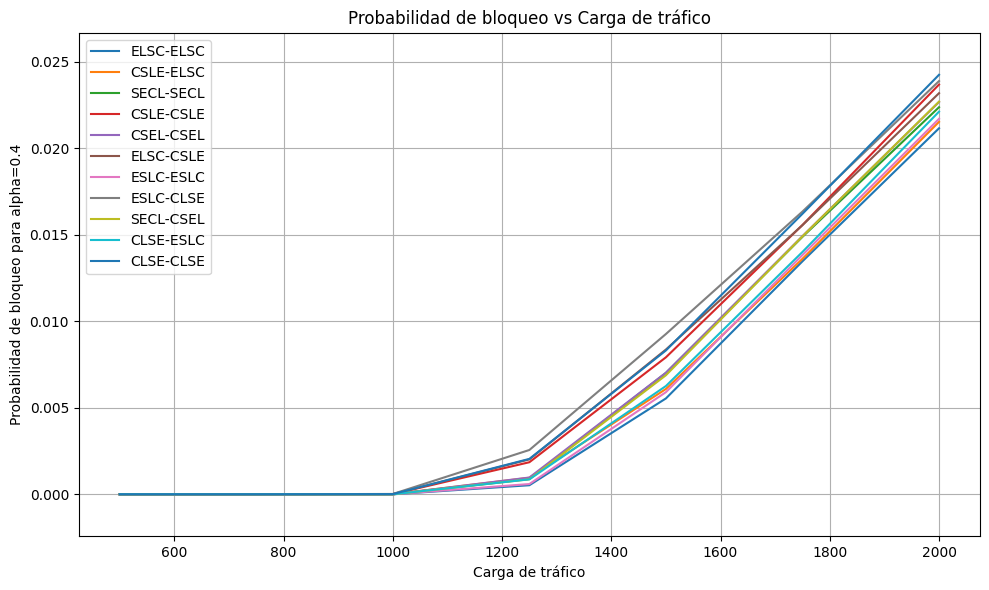

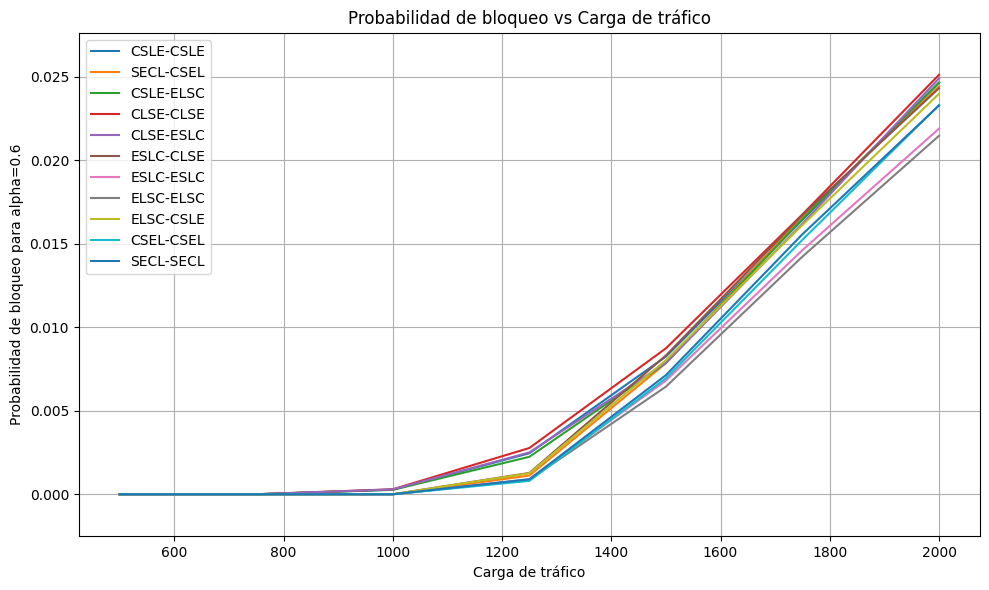

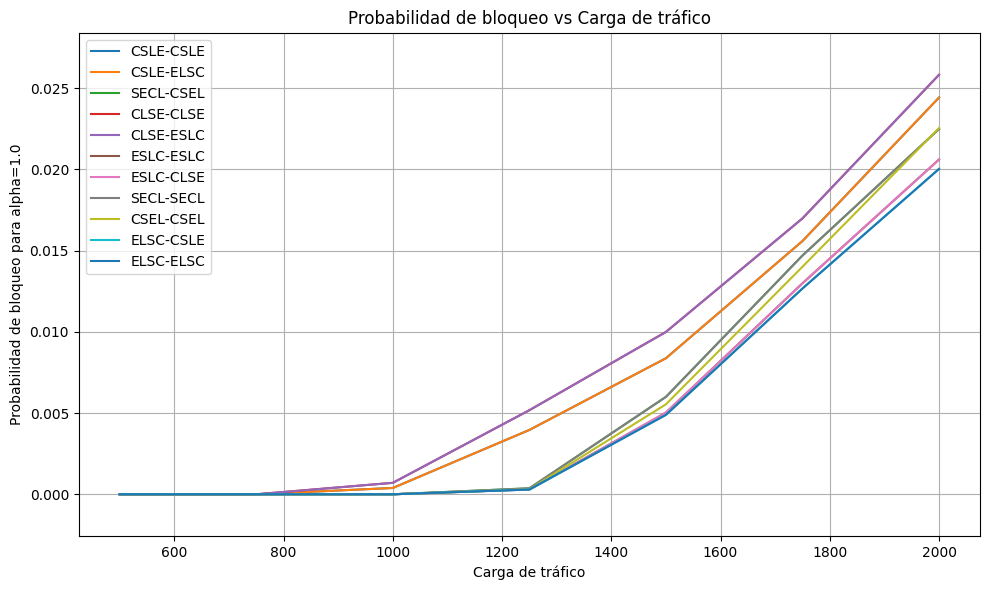

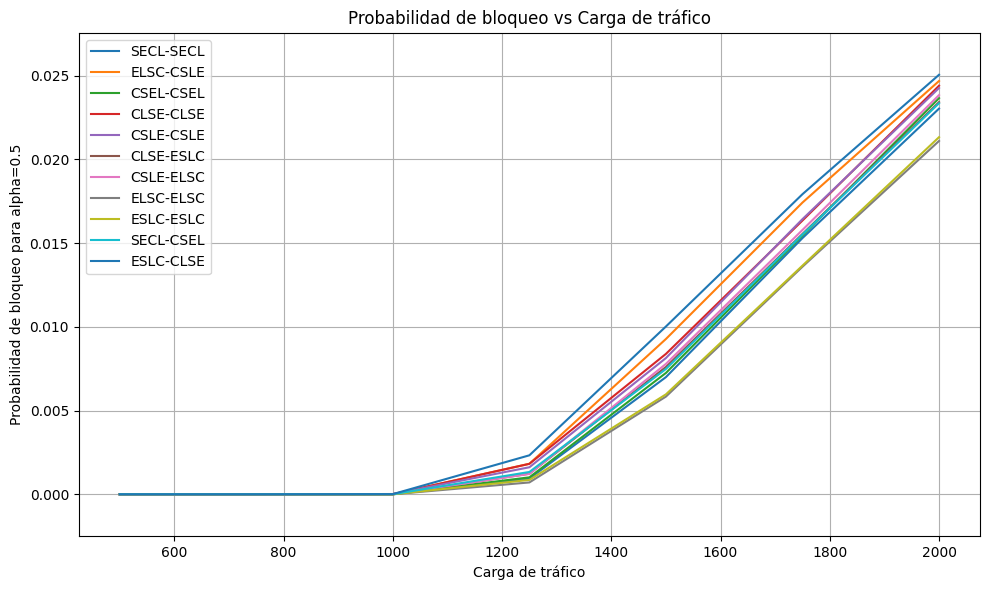

In [45]:
import matplotlib.pyplot as plt

block_prob: dict[str, list[tuple[str, float]]] = {}


for key, data in results.items():
    # key = "0.3"
    # data = results["0.3"]

    plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]

        plt.plot(eje_x, eje_y, label=order_key)
        plt.legend()
    # labels = [csv["order"] for csv in data if csv[]]
    # plt.scatter(eje_x, eje_y, color="blue")
    plt.margins(y=0.1)
    # Etiquetas y título
    plt.xlabel("Carga de tráfico")
    plt.ylabel(f"Probabilidad de bloqueo para alpha={key}")
    plt.title("Probabilidad de bloqueo vs Carga de tráfico")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Sacando mejor y peor


In [22]:
# Diferencia porcentual
import matplotlib.pyplot as plt
import numpy as np


block_prob: dict[str, list[tuple[str, float]]] = {}
valores = {}
ordenes = {}

for key, data in results.items():
    valores[key] = {}
    ordenes[key] = {}
    # key = "0.3"
    # data = results["0.3"]
    # print(key, data)
    # plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():
        if order_key == "ELSC-SECL" or order_key == "ELSC-CSEL":
            continue
        valor_clse = results["1.0"]["CLSE-CLSE"]
        pb = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in valor_clse
        ]
        pb_ordenados = sorted(pb, key=lambda p: p[0])
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        for ind, ((pb_x, pb_y), (pa_x, pa_y)) in enumerate(
            zip(pb_ordenados, pares_ordenados)
        ):
            if pb_y == 0:
                pares_ordenados[ind] = (pa_x, 0)
            else:
                pares_ordenados[ind] = (pa_x, (pa_y - pb_y) * 100 / pb_y)
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]

        for traffic, value in zip(eje_x, eje_y):
            if traffic not in valores[key]:
                valores[key][traffic] = []
                ordenes[key][traffic] = []
            valores[key][traffic].append(value)
            ordenes[key][traffic].append(order_key)


# if order_key == "ESLC-ESLC":

test = 1000.0
alpha = "0.7"
print(alpha)
print(np.argmax(valores[alpha][test]))
print(valores[alpha][test])
print(ordenes[alpha][test][np.argmax(valores[alpha][test])])
# plt.plot(eje_x, eje_y, label=order_key)

0.7
1
[-100.00000000000001, -10.35460992907802, -100.00000000000001, -100.00000000000001, -100.00000000000001, -100.00000000000001, -10.35460992907802, -100.00000000000001, -100.00000000000001, -44.25531914893617, -44.25531914893617]
CLSE-ESLC


In [ ]:
preguntas = [
    "Traer de regreso (devolver)",
    "Sacar / Publicar",
    "Cancelar",
    "Revisar de hacerse checkeo",
    "Regresar",
    "Entrar",
    "Salir a flote, salir a relucir",
    "Surgir",
    "Desmoronarse/desplomarse",
    "Encontrarse con",
    "Venir / Pasar",
    "Eliminar",
    "Dejar a alguien / Bajar",
    "Abandonar",
    "Llevarse bien",
    "Recuperar, Regresar",
    "Subir / Entrar",
    "Bajar",
    "Subir / Llevarse",
    "Sal, vete",
    "Superar",
    "Lograr / Comunicar",
    "Ceder",
    "Irse",
    "Volver",
    "Revisar",
    "Atravesar",
]
import numpy as np

np.random.shuffle(preguntas)
for i, p in enumerate(preguntas):
    print(f"{i+1}. {p}")

1. Salir
2. Cancelar
3. Subir / Llevarse
4. Encontrarse con
5. Recuperar, Regresar
6. Irse
7. Desmoronarse/desplomarse
8. Bajar
9. Salir a flote, salir a relucir
10. Dejar a alguien / Bajar
11. Revisar
12. Lograr / Comunicar
13. Subir / Entrar
14. Regresar
15. Sacar / Publicar
16. Entrar
17. Abandonar
18. Volver
19. Traer de regreso (devolver)
20. Revisar de hacerse checkeo
21. Ceder
22. Superar
23. Surgir
24. Atravesar
25. Eliminar
26. Venir / Pasar
27. Llevarse bien
